trying to find a pattern per age window
for each roi/component/network:
    try linear model, quadratic model: gmv_in_roi = b1(bitrh_year)+b2(sex)+b3(tiv)
    collect significance
    compare and pick the best of them 

map which rois are linear/quad/not significant

In [2]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [ ]:
# load data
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

In [6]:
# define parameters
age_windows = [(18, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65,100)]
roi_list = [421, 280]

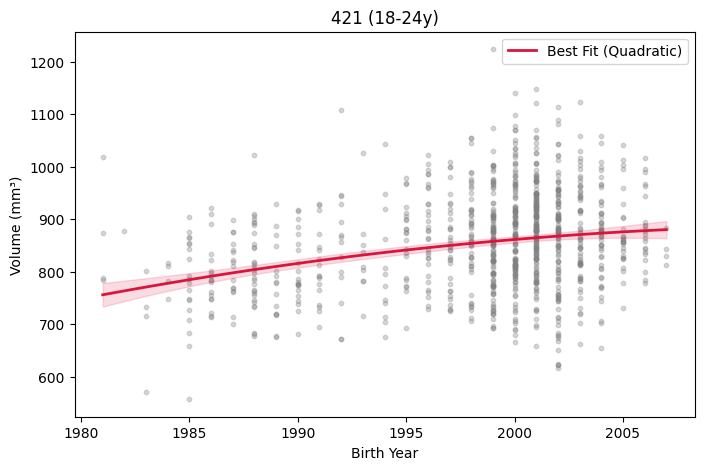

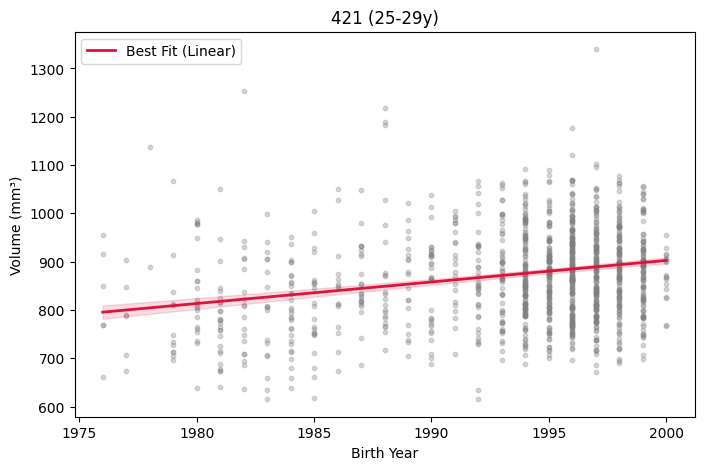

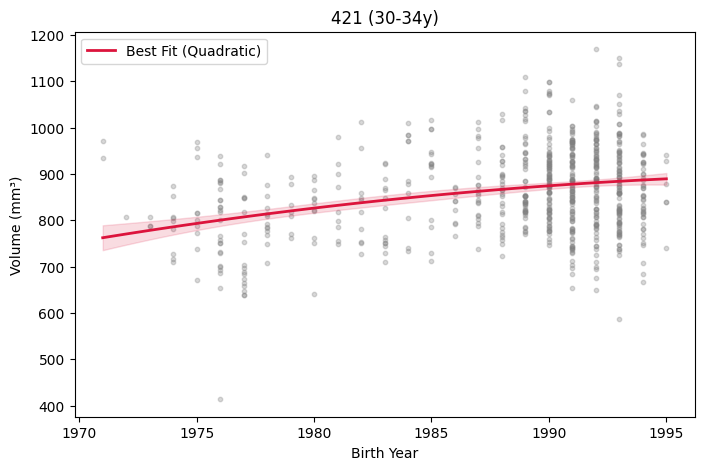

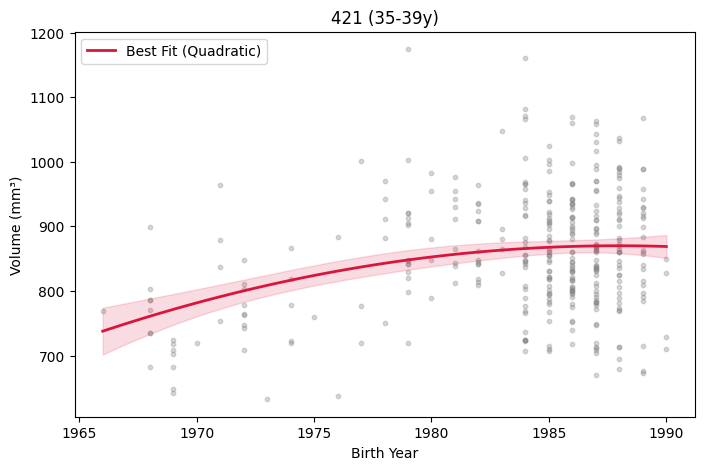

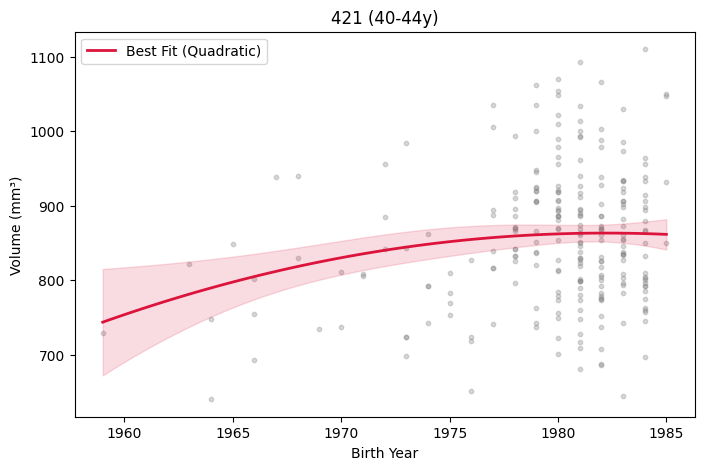

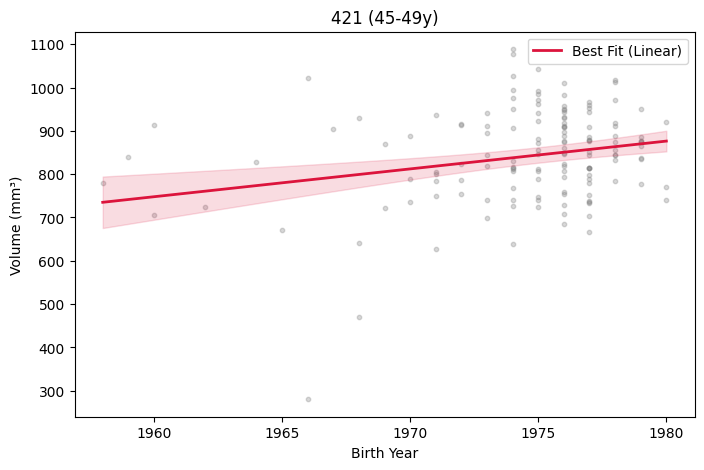

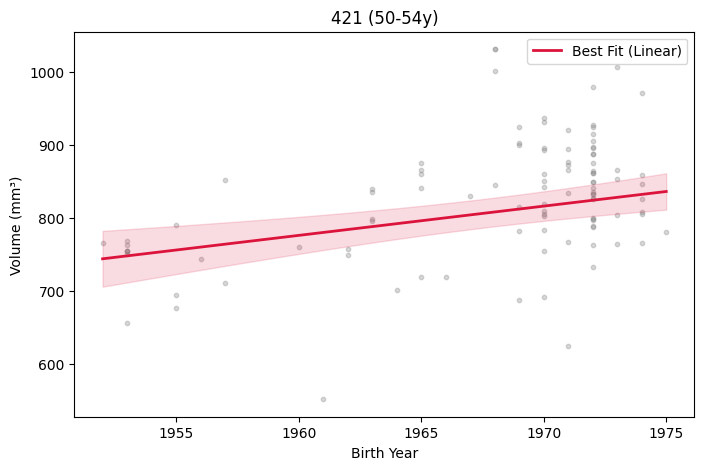

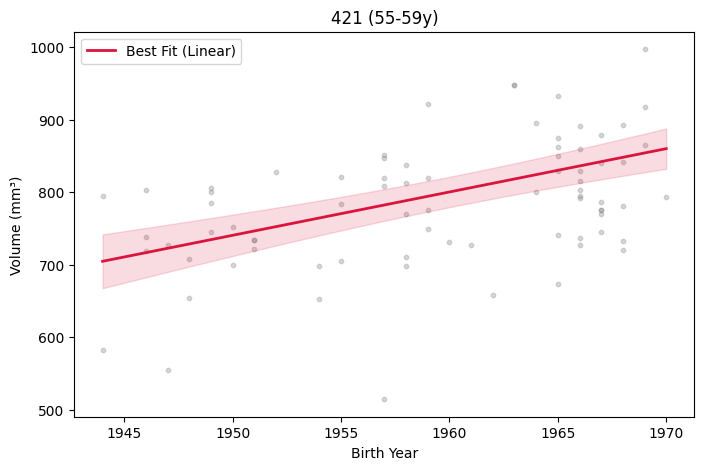

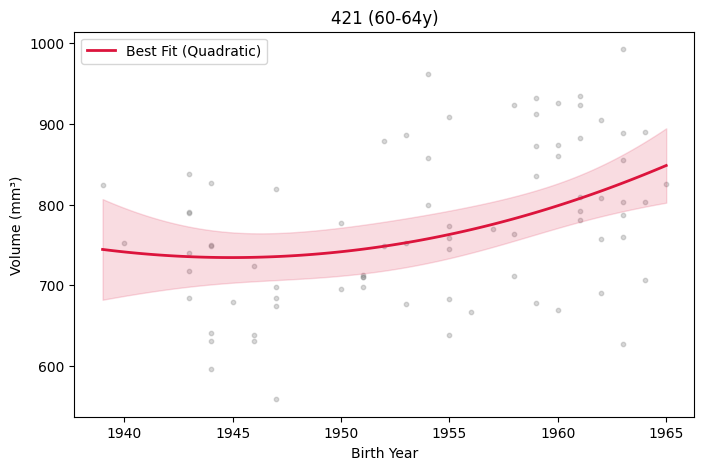

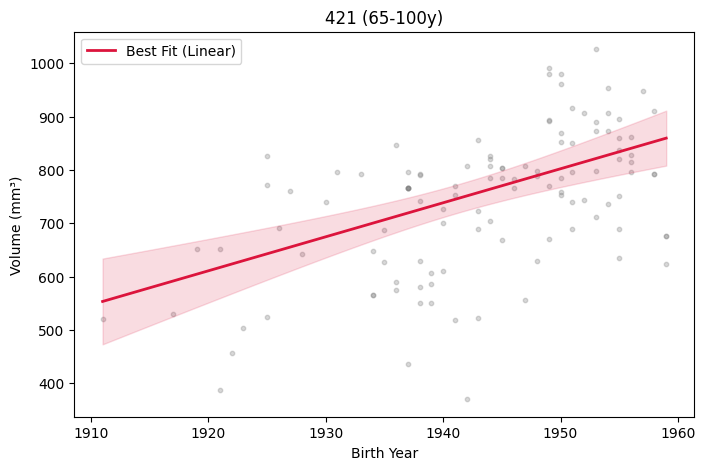

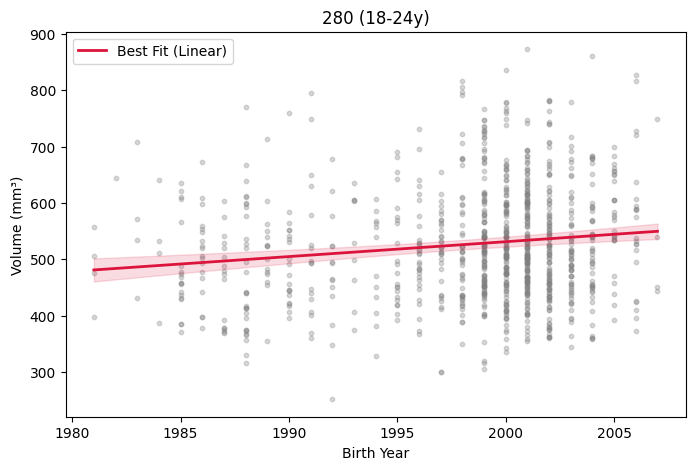

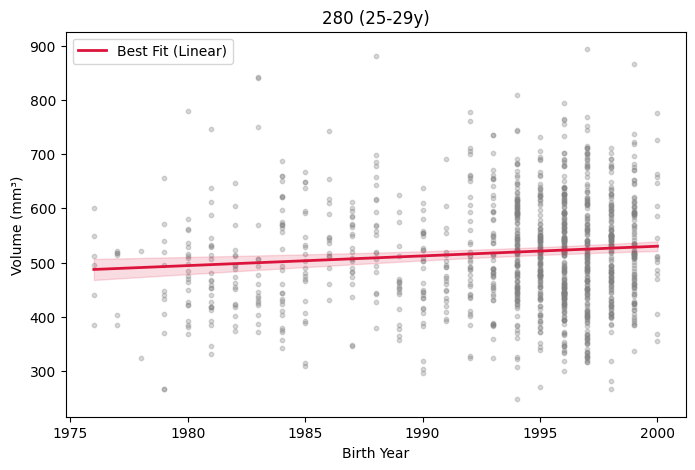

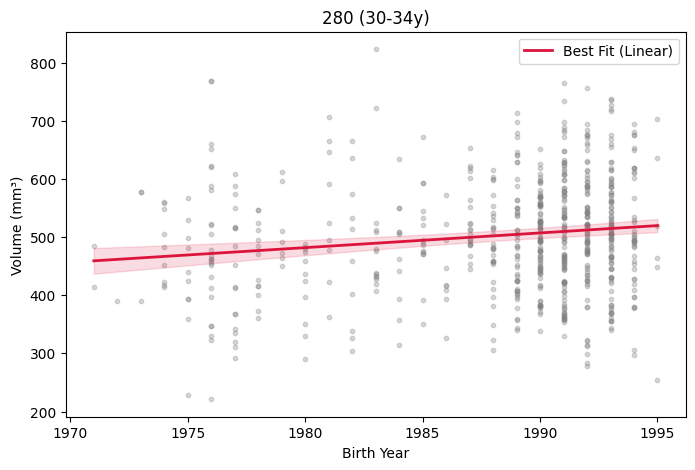

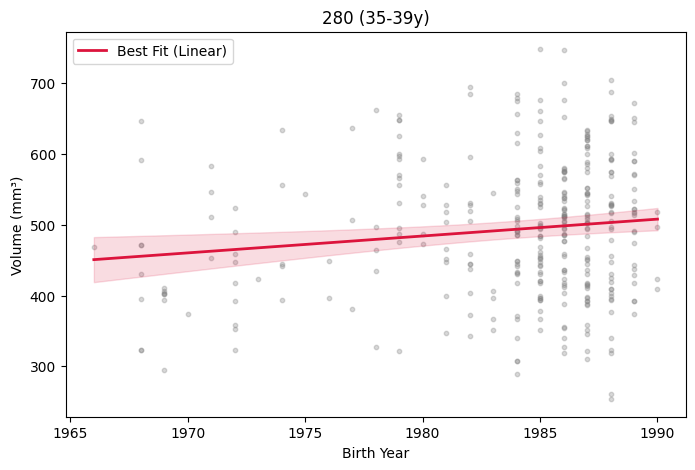

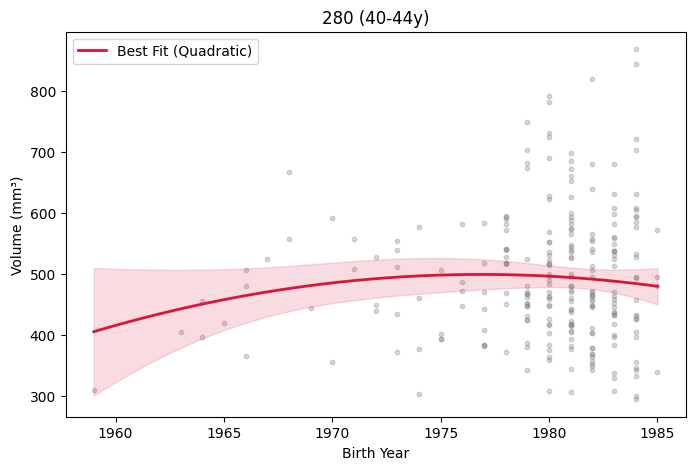

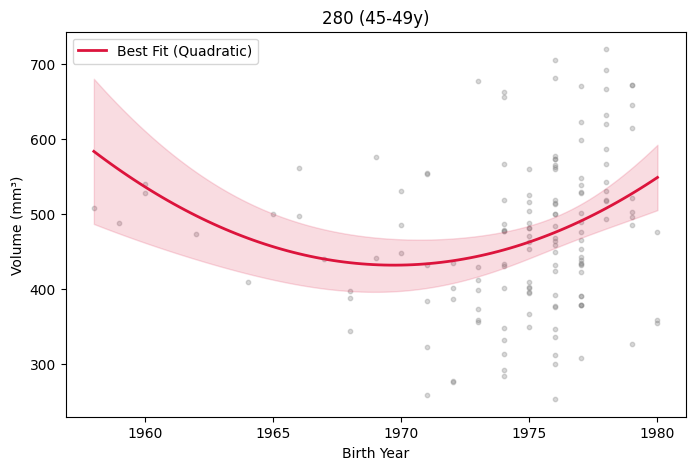

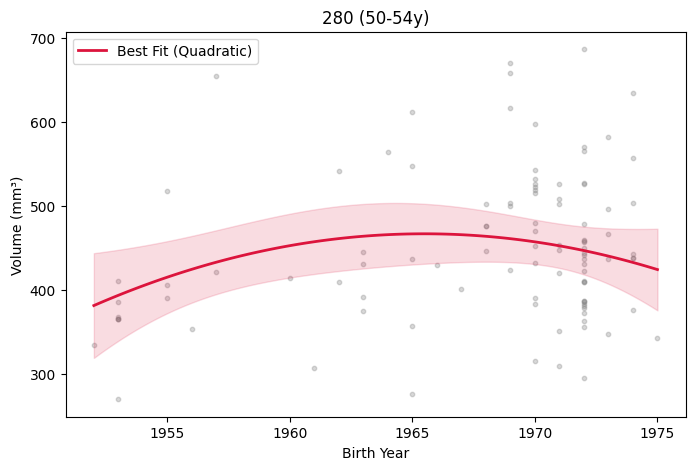

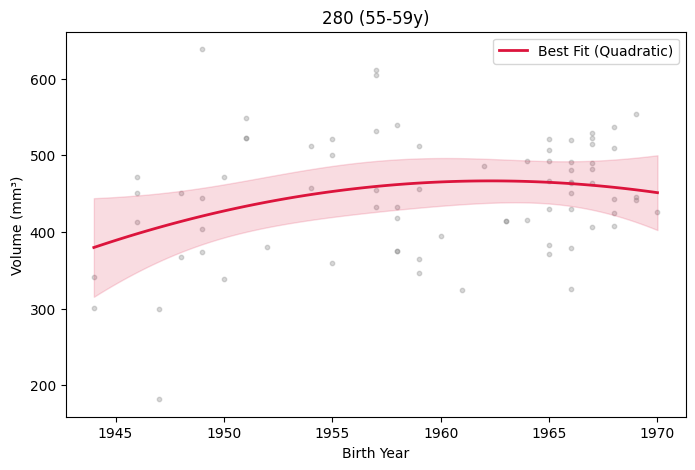

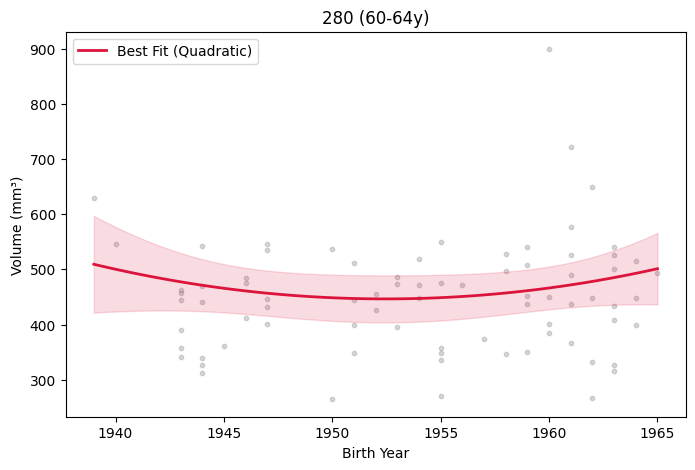

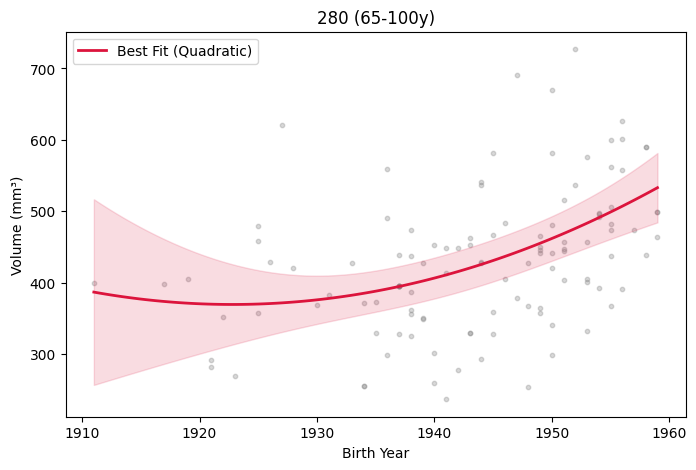

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Settings
MIN_SAMPLES = 20
alpha_level = 0.05
all_stats = []

# Define formulas once
formula_lin = 'volume_mm3 ~ birth_year + C(sex) + tiv + age_in_years'
formula_quad = 'volume_mm3 ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years'

for roi in roi_list:
    # Filter by ROI once
    roi_df_full = combined_df[combined_df['region_label'] == roi]
    
    for min_age, max_age in age_windows:
        # subsetting
        mask = (roi_df_full['age_in_years'] >= min_age) & (roi_df_full['age_in_years'] <= max_age)
        filtered_df = roi_df_full[mask].copy()
        
        if len(filtered_df) < MIN_SAMPLES:
            continue 

        # 1. Fit both models
        m_lin = smf.ols(formula_lin, data=filtered_df).fit()
        m_quad = smf.ols(formula_quad, data=filtered_df).fit()

        # 2. Model Selection Logic
        is_quad = m_quad.aic < m_lin.aic
        best_model = m_quad if is_quad else m_lin
        model_label = "Quadratic" if is_quad else "Linear"

        # 3. Store Statistics
        all_stats.append({
            'roi': roi,
            'age_window': f"{min_age}-{max_age}",
            'model_type': model_label,
            'aic_lin': m_lin.aic,
            'aic_quad': m_quad.aic,
            'aic_diff': m_lin.aic - m_quad.aic,
            'lin_coeff': best_model.params.get('birth_year'),
            'lin_p': best_model.pvalues.get('birth_year'),
            'quad_coeff': best_model.params.get('I(birth_year ** 2)', np.nan),
            'quad_p': best_model.pvalues.get('I(birth_year ** 2)', np.nan),
            'r2_adj': best_model.rsquared_adj
        })

        # 4. Optimized Plotting
        # Only plot if you really need 100+ windows, otherwise consider wrapping in an 'if'
        fig, ax = plt.subplots(figsize=(8, 5))
        
        # Grid for prediction
        by_min, by_max = filtered_df['birth_year'].agg(['min', 'max'])
        by_range = np.linspace(by_min, by_max, 100)
        
        predict_df = pd.DataFrame({
            'birth_year': by_range,
            'sex': filtered_df['sex'].mode()[0],
            'tiv': filtered_df['tiv'].mean(),
            'age_in_years': filtered_df['age_in_years'].mean()
        })

        preds = best_model.get_prediction(predict_df).summary_frame()

        # Visualization
        ax.scatter(filtered_df['birth_year'], filtered_df['volume_mm3'], alpha=0.3, c='gray', s=10)
        ax.plot(by_range, preds['mean'], color='crimson', lw=2, label=f'Best Fit ({model_label})')
        ax.fill_between(by_range, preds['mean_ci_lower'], preds['mean_ci_upper'], color='crimson', alpha=0.15)
        
        ax.set(title=f"{roi} ({min_age}-{max_age}y)", xlabel="Birth Year", ylabel="Volume (mm³)")
        ax.legend()
        plt.show()

# --- Post-Processing ---
stats_df = pd.DataFrame(all_stats)

if not stats_df.empty:
    # Correcting the linear term p-values (most common point of interest)
    stats_df['p_fdr_corrected'] = multipletests(stats_df['lin_p'], method='fdr_bh')[1]